<a href="https://colab.research.google.com/github/JuanBeltran0397/Simulacion/blob/main/AD2_M1_Juan_Beltran_Camilo_Alegria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import random
from collections import Counter #Para contar cuántas veces aparece un número.
import matplotlib.pyplot as plt #Para los histogramas


# INICIO

print ("Cuantas simulaciones requiere: \n")
simulaciones = int(input())
SIMULACIONES = simulaciones #numero de simulaciones
random.seed(10) #Mascara de bloquelo

categorias = [
    "unos",
    "doses",
    "treses",
    "cuatros",
    "cincos",
    "seises",
    "trio",
    "poker",
    "full",
    "escalera_corta",
    "escalera_larga",
    "yahtzee",
    "chance"
]


# ESTADÍSTICAS


total_lanzamientos = 0
contador_caras = Counter()


# FUNCIONES

# la funcion genera un numero aleatorio entre 1 y 6
def lanzar_dado():
    return random.randint(1, 6)

# esta funcion se encarga de guardar la informacion para posteriormente realizar los analisis
def guardar_estadisticas(dados):

    global total_lanzamientos
    global contador_caras

    total_lanzamientos += len(dados)

    contador_caras.update(dados)

# esta funcion se encarga de lanzar el conjunto de dados acorde a si se encuentran bloqueados o no
def lanzar_dados(dados, guardar):

    for i in range(5):

        if not guardar[i]:
            dados[i] = lanzar_dado()

    guardar_estadisticas(dados)

# esta funcion determina si el jugador realizo escalera corta o larga
def revisar_escalera(dados, cantidad):

    numeros = sorted(set(dados))

    consecutivos = 1
    mayor = 1

    for i in range(1, len(numeros)):

        if numeros[i] == numeros[i - 1] + 1:
            consecutivos += 1
            mayor = max(mayor, consecutivos)

        else:
            consecutivos = 1

    return mayor >= cantidad



# FUNCIONES DE PUNTOS

# se encarga de determinar las puntuaciones acorde a las categorias disponibles y los dados lanzados
def calcular_puntos(categoria, dados):

    contador = Counter(dados)

    total = sum(dados)

    cantidades = list(contador.values())

    if categoria == "unos":
        return contador[1] * 1

    elif categoria == "doses":
        return contador[2] * 2

    elif categoria == "treses":
        return contador[3] * 3

    elif categoria == "cuatros":
        return contador[4] * 4

    elif categoria == "cincos":
        return contador[5] * 5

    elif categoria == "seises":
        return contador[6] * 6

    elif categoria == "trio":

        if max(cantidades) >= 3:
            return total

        return 0

    elif categoria == "poker":

        if max(cantidades) >= 4:
            return total

        return 0

    elif categoria == "full":

        if 3 in cantidades and 2 in cantidades:
            return 25

        return 0

    elif categoria == "escalera_corta":

        if revisar_escalera(dados, 4):
            return 30

        return 0

    elif categoria == "escalera_larga":

        if revisar_escalera(dados, 5):
            return 40

        return 0

    elif categoria == "yahtzee":

        if max(cantidades) == 5:
            return 50

        return 0

    elif categoria == "chance":
        return total

    return 0



# BUSCAR MEJOR CATEGORÍA

# esta funcion se encarga de realizar la inspeccion de los puntajes acorde a su mejor categoria
def mejor_categoria(dados, categorias_disponibles):

    mejor = ""
    mejor_puntaje = -1

    for cat in categorias_disponibles:

        puntos = calcular_puntos(cat, dados)

        if puntos > mejor_puntaje:
            mejor_puntaje = puntos
            mejor = cat

    return mejor, mejor_puntaje



# MONTECARLO

# simula las posibles mejores puntuaciones
def probar_jugada(dados_actuales, guardar, tiros_restantes,categorias_disponibles):

    suma_puntos = 0

    for _ in range(SIMULACIONES):

        copia = dados_actuales[:]

        for _ in range(tiros_restantes):

            for i in range(5):

                if not guardar[i]:
                    copia[i] = lanzar_dado()

        cate , puntos = mejor_categoria(copia, categorias_disponibles)

        suma_puntos += puntos

    return suma_puntos / SIMULACIONES

# esta funcion se encarga de decidir cual dado se bloquea
def decidir_guardar(dados_actuales, tiros_restantes, categorias_disponibles):

    mejor_opcion = [False] * 5
    mejor_promedio = -1

    # 32 combinaciones posibles
    for numero in range(32):

        guardar = []

        for i in range(5):

            guardar.append((numero >> i) & 1 == 1)

        promedio = probar_jugada(dados_actuales, guardar, tiros_restantes - 1, categorias_disponibles)

        if promedio > mejor_promedio:

            mejor_promedio = promedio
            mejor_opcion = guardar

    return mejor_opcion



# CLASE JUGADOR

# se declara la clase jugador la cual contiene diccionario de puntajes y el nombre del jugador
class Jugador:

    def __init__(self, nombre):

        self.nombre = nombre

        self.puntajes = {}

        for cat in categorias:
            self.puntajes[cat] = None

        self.total = 0
    # este metodo se encarga de revisar cuales categorias aun no cuentan con puntajes
    def categorias_libres(self):

        libres = []

        for cat in self.puntajes:

            if self.puntajes[cat] is None:
                libres.append(cat)

        return libres
    # este metodo se encarga de guardar los puntajes acorde a las categorias y suma el puntaje total del jugador
    def guardar_puntos(self, categoria, puntos):

        self.puntajes[categoria] = puntos

        self.total = sum( valor
            for valor in self.puntajes.values()
            if valor is not None
        )



# TURNO

# se define la funcion jugar turno la cual se encarga de realizar y guardar cada una de las tiradas de los jugadores
def jugar_turno(jugador):

    print(f"\nTurno de {jugador.nombre}")

    dados = [0, 0, 0, 0, 0]

    guardar = [False] * 5

    tiros = 3

    # primera tirada
    lanzar_dados(dados, guardar)

    tiros -= 1

    print("Tirada 1:", dados)

    while tiros > 0:

        decision = decidir_guardar( dados,
          tiros,
            jugador.categorias_libres()
        )

        # si decide guardar todos
        if all(decision):

            print(
                "El jugador decide quedarse con:",
                dados
            )

            break

        guardar = decision

        lanzar_dados(dados, guardar)

        numero_tirada = 3 - tiros + 1

        print("Tirada", numero_tirada, ":", dados)

        print("Dados Bloqueados: ", guardar)

        tiros -= 1

    categoria, puntos = mejor_categoria(dados, jugador.categorias_libres())

    jugador.guardar_puntos(categoria, puntos)

    print("Categoría elegida:", categoria)

    print("Puntos ganados:", puntos)

    print("Total acumulado:", jugador.total)



# PARTIDA COMPLETA

# se intancian los jugadores
jugador1 = Jugador("Jugador 1")

jugador2 = Jugador("Jugador 2")

print("INICIANDO PARTIDA DE YAHTZEE")

for ronda in range(13):

    print(f"\nRONDA {ronda + 1}")

    jugar_turno(jugador1)

    jugar_turno(jugador2)



# RESULTADOS FINALES

# trae todos los valores y los muestra realizando ajuste a las categorias con None asigandole valor de 0
print("\nRESULTADOS FINALES")

for jugador in [jugador1, jugador2]:

    print(f"\n{jugador.nombre}")

    print("Total:", jugador.total)

    for cat in categorias:

        valor = jugador.puntajes[cat]

        if valor is None:
            valor = 0

        print(f"{cat}: {valor}")



# GANADOR

# esta parte del codigo determina he imprime cual fue el jugador ganador acorde a las puntuaciones
print("\nGANADOR")

if jugador1.total > jugador2.total:

    print("Gana Jugador 1")

elif jugador2.total > jugador1.total:

    print("Gana Jugador 2")

else:

    print("Empate")




Cuantas simulaciones requiere: 

1000
INICIANDO PARTIDA DE YAHTZEE

RONDA 1

Turno de Jugador 1
Tirada 1: [5, 1, 4, 4, 5]
Tirada 2 : [2, 6, 4, 2, 5]
Dados Bloqueados:  [False, False, True, False, True]
Tirada 3 : [6, 3, 5, 4, 6]
Dados Bloqueados:  [False, False, False, False, False]
Categoría elegida: escalera_corta
Puntos ganados: 30
Total acumulado: 30

Turno de Jugador 2
Tirada 1: [1, 3, 1, 1, 6]
Tirada 2 : [3, 3, 3, 6, 6]
Dados Bloqueados:  [False, True, False, False, True]
Tirada 3 : [5, 3, 2, 6, 4]
Dados Bloqueados:  [False, False, False, False, False]
Categoría elegida: escalera_larga
Puntos ganados: 40
Total acumulado: 40

RONDA 2

Turno de Jugador 1
Tirada 1: [4, 5, 6, 6, 4]
El jugador decide quedarse con: [4, 5, 6, 6, 4]
Categoría elegida: chance
Puntos ganados: 25
Total acumulado: 55

Turno de Jugador 2
Tirada 1: [4, 3, 3, 1, 5]
Tirada 2 : [4, 2, 3, 3, 5]
Dados Bloqueados:  [True, False, True, False, True]
Tirada 3 : [2, 1, 5, 1, 2]
Dados Bloqueados:  [False, False, False, F

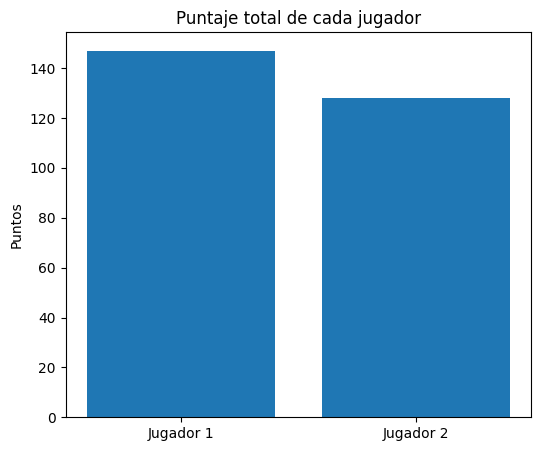

In [9]:

# PUNTAJE TOTAL DE CADA JUGADOR


jugadores = ["Jugador 1", "Jugador 2"]

puntajes = [
    jugador1.total,
    jugador2.total
]

plt.figure(figsize=(6,5))

plt.bar(jugadores, puntajes)

plt.title("Puntaje total de cada jugador")

plt.ylabel("Puntos")

plt.show()

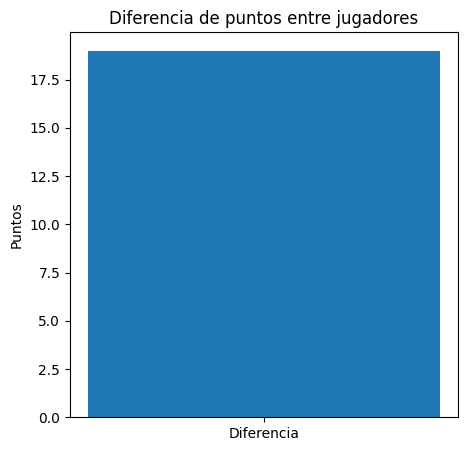

In [10]:

# DIFERENCIA DE PUNTOS


diferencia = abs(
    jugador1.total - jugador2.total
)

plt.figure(figsize=(5,5))

plt.bar(
    ["Diferencia"],
    [diferencia]
)

plt.title("Diferencia de puntos entre jugadores")

plt.ylabel("Puntos")

plt.show()

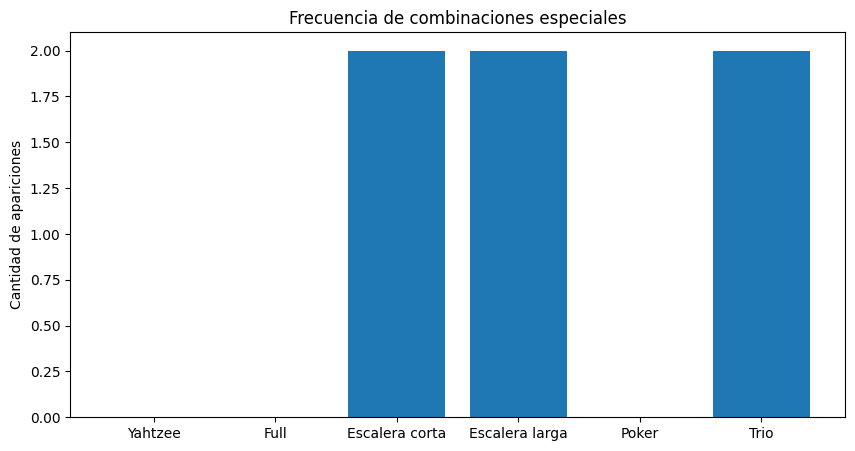

In [11]:

# FRECUENCIA DE COMBINACIONES


combinaciones = {
    "Yahtzee": 0,
    "Full": 0,
    "Escalera corta": 0,
    "Escalera larga": 0,
    "Poker": 0,
    "Trio": 0
}

for jugador in [jugador1, jugador2]:

    if jugador.puntajes["yahtzee"] > 0:
        combinaciones["Yahtzee"] += 1

    if jugador.puntajes["full"] > 0:
        combinaciones["Full"] += 1

    if jugador.puntajes["escalera_corta"] > 0:
        combinaciones["Escalera corta"] += 1

    if jugador.puntajes["escalera_larga"] > 0:
        combinaciones["Escalera larga"] += 1

    if jugador.puntajes["poker"] > 0:
        combinaciones["Poker"] += 1

    if jugador.puntajes["trio"] > 0:
        combinaciones["Trio"] += 1

nombres = list(combinaciones.keys())

valores = list(combinaciones.values())

plt.figure(figsize=(10,5))

plt.bar(nombres, valores)

plt.title("Frecuencia de combinaciones especiales")

plt.ylabel("Cantidad de apariciones")

plt.show()

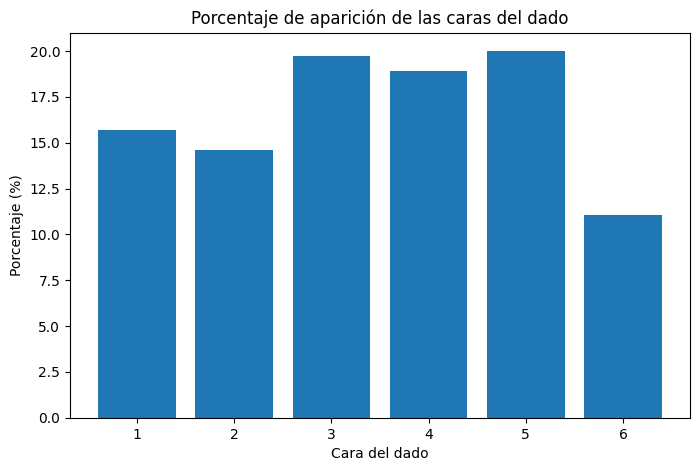

In [12]:

# HISTOGRAMA CARA DE DADOS


caras = [1, 2, 3, 4, 5, 6]

porcentajes = []

for cara in caras:

    porcentaje = (
        contador_caras[cara] / total_lanzamientos
    ) * 100

    porcentajes.append(porcentaje)

plt.figure(figsize=(8,5))

plt.bar(caras, porcentajes)

plt.title("Porcentaje de aparición de las caras del dado")

plt.xlabel("Cara del dado")

plt.ylabel("Porcentaje (%)")

plt.xticks(caras)

plt.show()

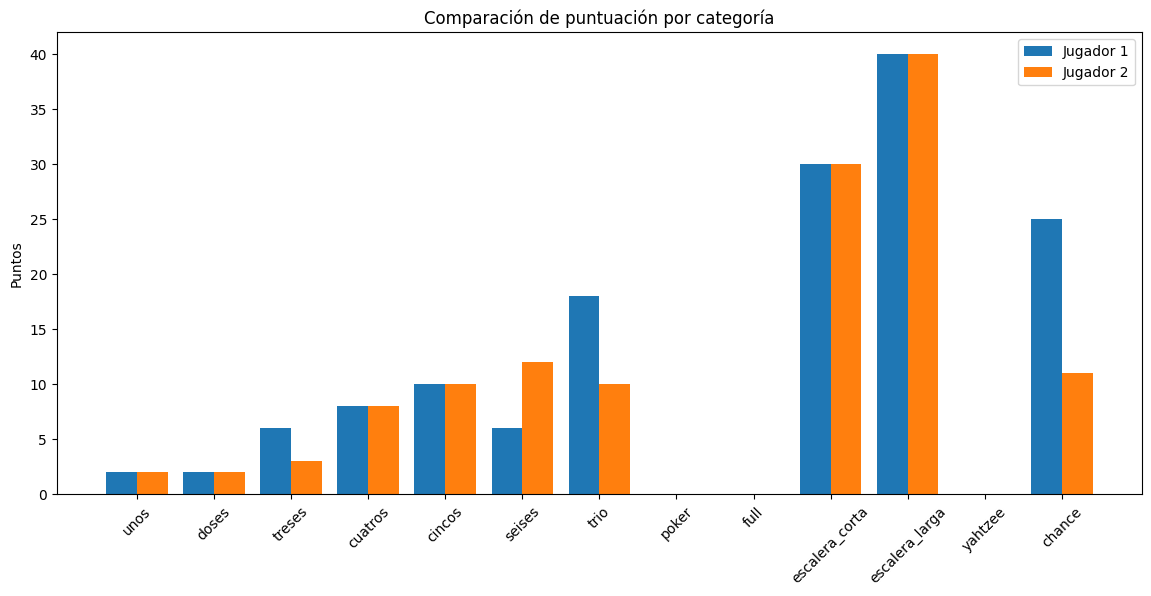

In [15]:

# COMPARACIÓN JUGADORES


categorias_grafica = categorias

puntos_jugador1 = []
puntos_jugador2 = []

for cat in categorias_grafica:

    valor1 = jugador1.puntajes[cat]
    valor2 = jugador2.puntajes[cat]

    if valor1 is None:
        valor1 = 0

    if valor2 is None:
        valor2 = 0

    puntos_jugador1.append(valor1)
    puntos_jugador2.append(valor2)

x = range(len(categorias_grafica))

ancho = 0.4

plt.figure(figsize=(14,6))

plt.bar(
    [i - ancho/2 for i in x],
    puntos_jugador1,
    width=ancho,
    label="Jugador 1"
)

plt.bar(
    [i + ancho/2 for i in x],
    puntos_jugador2,
    width=ancho,
    label="Jugador 2"
)

plt.xticks(x, categorias_grafica, rotation=45)

plt.ylabel("Puntos")

plt.title("Comparación de puntuación por categoría")

plt.legend()

plt.show()